# Tutorial 3.3a: batch size = 16

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import numpy as np
import matplotlib.pylab as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

## Set learning parameters

In [2]:
no_epochs = 1000
batch_size = 16
lr = 0.01

SEED = 100
torch.manual_seed(SEED)
np.random.seed(SEED)

no_inputs = 4
no_outputs = 3

## Read iris data

In [3]:
iris = datasets.load_iris()
iris.data -= np.mean(iris.data, axis=0)
    
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=2)

print(np.shape(x_train))
print(np.shape(y_test))

(90, 4)
(60,)


## Convert the data into pytorch Datasets

In [4]:
# create a subclass of Dataset class
class MyDataset(Dataset):
  def __init__(self, X, y):
    self.X =torch.tensor(X, dtype=torch.float)
    self.y =torch.tensor(y, dtype=torch.long)
    
  def __len__(self):
    return len(self.y)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [5]:
# create Dataset objectives
train_data = MyDataset(x_train, y_train)
test_data = MyDataset(x_test, y_test)

# create dataloaders for minibatch learning
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Build the model

In [6]:
# create a SoftmaxLayer as a subclass of nn.Module
class SoftmaxLayer(nn.Module):
  def __init__(self, no_inputs, no_outputs):
        super().__init__()
        self.softmax_layer = nn.Sequential(
            nn.Linear(no_inputs, no_outputs)
        )

  def forward(self, x):
        logits = self.softmax_layer(x)
        return logits

In [7]:
# create a model objective
model = SoftmaxLayer(no_inputs, no_outputs)

# print the model structure
print(f"{model}\n")

# print model parameters
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param} \n")

SoftmaxLayer(
  (softmax_layer): Sequential(
    (0): Linear(in_features=4, out_features=3, bias=True)
  )
)

Layer: softmax_layer.0.weight | Size: torch.Size([3, 4]) | Values : Parameter containing:
tensor([[-0.3883,  0.3158, -0.2374, -0.0161],
        [ 0.1765,  0.2539, -0.2373, -0.4572],
        [-0.2920, -0.3820, -0.3783,  0.2356]], requires_grad=True) 

Layer: softmax_layer.0.bias | Size: torch.Size([3]) | Values : Parameter containing:
tensor([ 0.2118,  0.2876, -0.0817], requires_grad=True) 



## Functions for one epoch of training and testing

In [8]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    train_loss /= size
    correct /= size
    return train_loss, correct
    

def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(dim=1) == y).type(torch.float).sum().item()

    test_loss /= size
    correct /= size
 
    return test_loss, correct
    

## Train the model

In [9]:
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

train_loss_, train_acc_, test_loss_, test_acc_ = [], [], [], []

for epoch in range(no_epochs):
    train_loss, train_acc = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_acc = test_loop(test_dataloader, model, loss_fn)
    
    train_loss_.append(train_loss), train_acc_.append(train_acc)
    test_loss_.append(test_loss), test_acc_.append(test_acc)
    
    if epoch%100 == 99:
        print(f"Epoch {epoch+1}, train_loss {train_loss:>7f} train_acc {train_acc:>4f}, test_loss {test_loss:>7f}, test_acc {test_acc:>4f}")
print("Done!")

Epoch 100, train_loss 0.121221 train_acc 0.966667, test_loss 0.128520, test_acc 0.950000
Epoch 200, train_loss 0.091407 train_acc 0.966667, test_loss 0.100666, test_acc 0.950000
Epoch 300, train_loss 0.078950 train_acc 0.966667, test_loss 0.088784, test_acc 0.950000
Epoch 400, train_loss 0.072564 train_acc 0.966667, test_loss 0.082061, test_acc 0.950000
Epoch 500, train_loss 0.067800 train_acc 0.966667, test_loss 0.078542, test_acc 0.950000
Epoch 600, train_loss 0.064452 train_acc 0.966667, test_loss 0.076107, test_acc 0.950000
Epoch 700, train_loss 0.062108 train_acc 0.966667, test_loss 0.074940, test_acc 0.950000
Epoch 800, train_loss 0.060709 train_acc 0.966667, test_loss 0.074361, test_acc 0.950000
Epoch 900, train_loss 0.059006 train_acc 0.966667, test_loss 0.074252, test_acc 0.950000
Epoch 1000, train_loss 0.057639 train_acc 0.966667, test_loss 0.074569, test_acc 0.950000
Done!


## Print final weights and biases

In [10]:
w = model.state_dict()['softmax_layer.0.weight'].numpy()
b = model.state_dict()['softmax_layer.0.bias'].numpy()

print('weight = {}, \nbias = {}'.format(w, b))

weight = [[-0.9832266   2.4068246  -4.980798   -2.0996215 ]
 [ 0.4294632  -0.6306771  -0.2859605  -3.130158  ]
 [ 0.04995771 -1.5883615   4.413687    4.9921026 ]], 
bias = [-0.6745619  5.2312255 -4.1390324]


## Plot learning curves

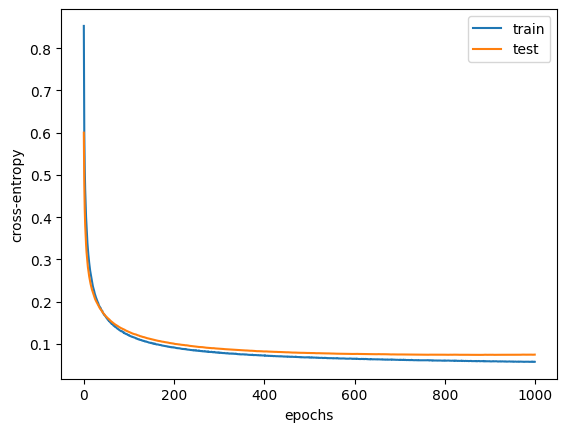

In [11]:
# plot cross-entropy loss for train and test data
plt.figure(1)
plt.plot(range(no_epochs), train_loss_, label='train')
plt.plot(range(no_epochs), test_loss_, label = "test")
plt.xlabel('epochs')
plt.ylabel('cross-entropy')
plt.legend()
plt.show()

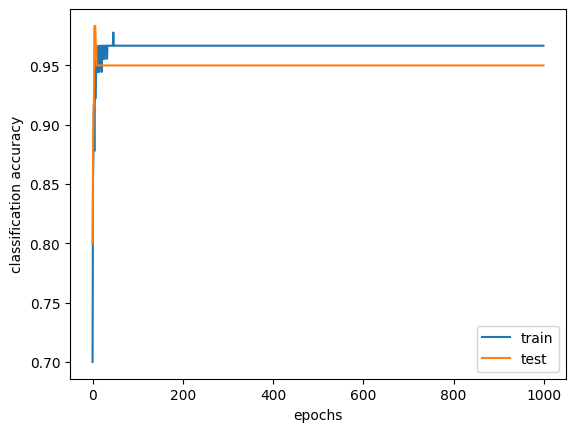

In [12]:
# plot classification accuracy for train and test data
plt.figure(2)
plt.plot(range(no_epochs), train_acc_, label='train')
plt.plot(range(no_epochs), test_acc_, label='test')
plt.xlabel('epochs')
plt.ylabel('classification accuracy')
plt.legend()
plt.show()